<a href="https://colab.research.google.com/github/emgrimm42/NLP-Hausarbeit/blob/main/analyse_3_worth_ufigkeit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
import plotly.graph_objects as go

Nun da wir uns die zeitliche Aufteilung von Lügenpresse-Synonymen angeschaut haben wäre es vielleicht auch interessant sich anzuschauen wie häufig die einzelnen Synonyme benutzt wurden.

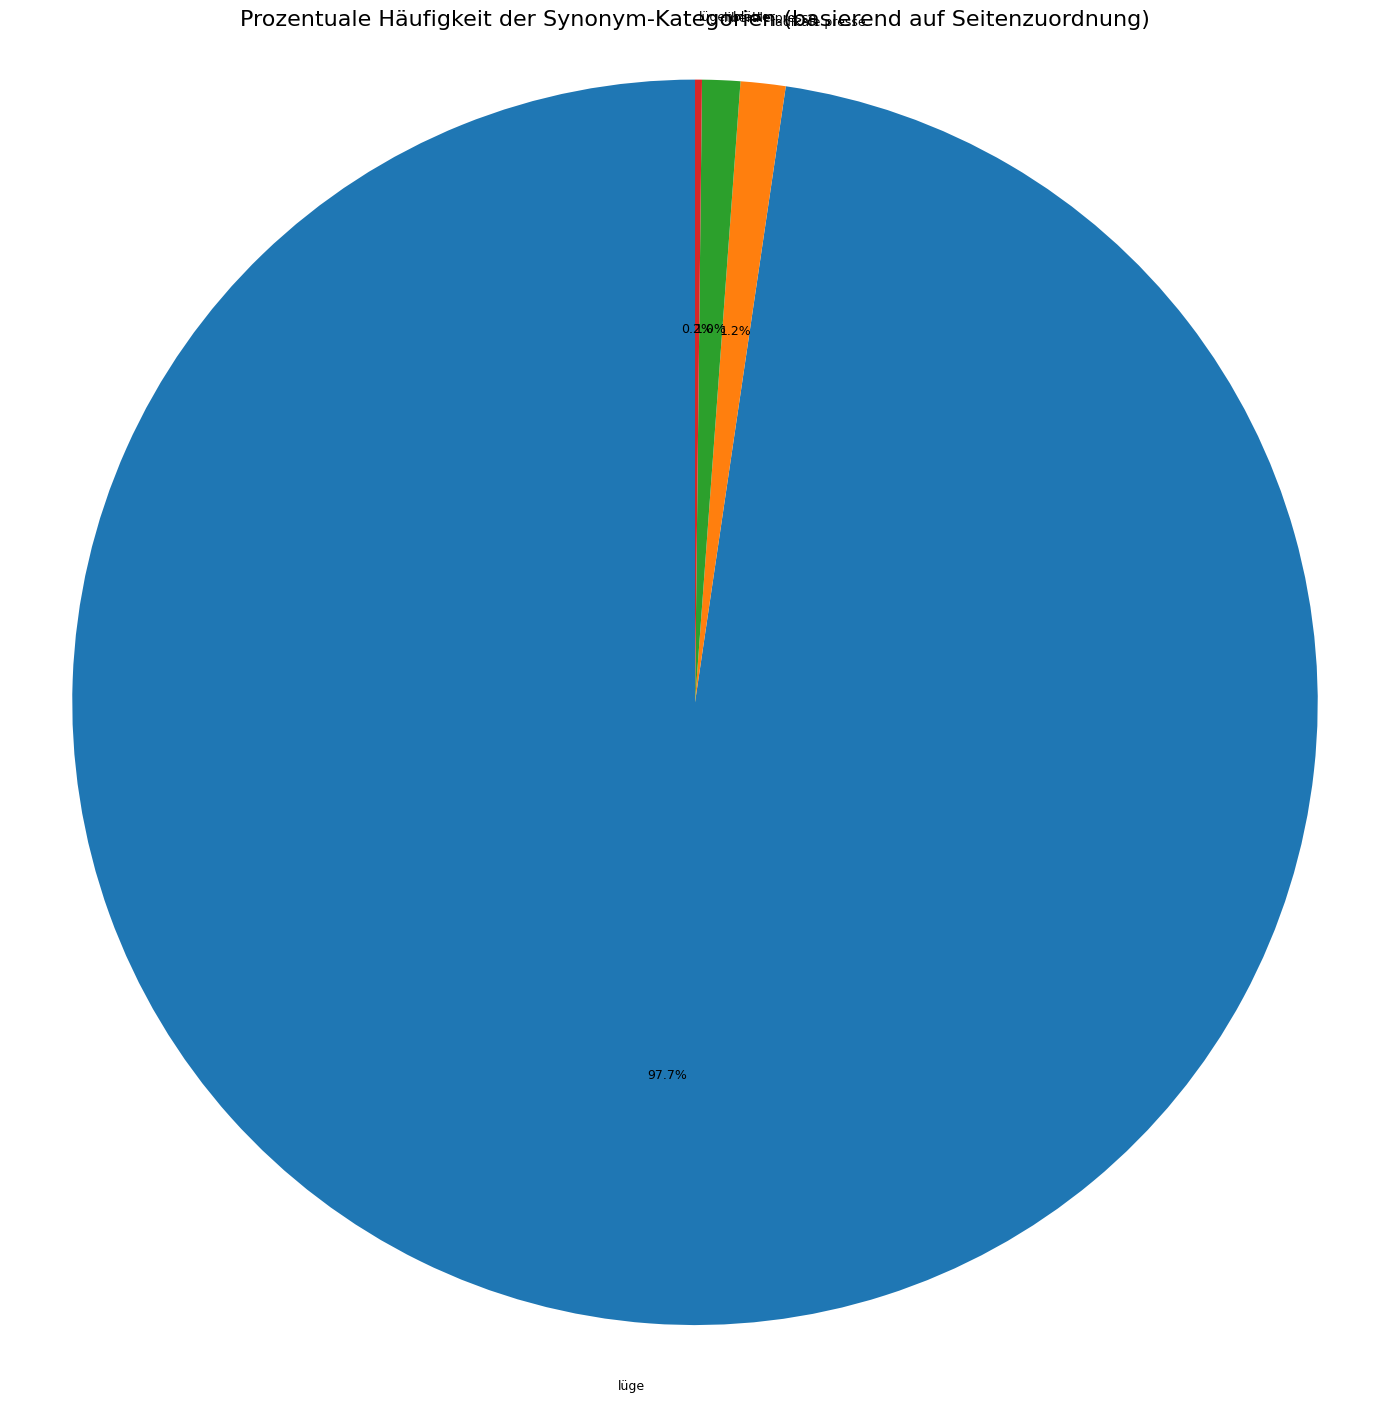

Statistik zur Häufigkeit der Synonym-Kategorien (Anzahl der Seiten, auf denen das Synonym vorkommt):


,Anzahl der Seiten
lüge,1090
radikale presse,13
liberale presse,11
lügenblätter,2


In [ ]:
import re

# --- Re-create df and df_synonyme to ensure consistency and correct processing ---
# This ensures that df and df_synonyme are defined correctly even if the kernel state was reset or altered.

# 1. Load the original data (df)
df = pd.read_excel('/content/Kopie von Synonyme_2751569-2.xlsx')

# 2. Convert text to lowercase for case-insensitive searching
df['plainpagefulltext'] = df['plainpagefulltext'].str.lower()

# 3. Define the full synonym list (as per cell nGu0G-MO9QVU)
synonyme = ["lüge",
    "lügenpresse",
    "falschmeldung",
    "lügenblatt",
    "lügenblätter",
    "hetzblatt",
    "hetzpresse",
    "schmierblatt",
    "schmierpresse",
    "pamphletpresse",
    "parteipresse",
    "demagogenpresse",
    "revolutionspresse",
    "radikale presse",
    "ultraradikale presse",
    "jüdische presse",
    "judenpresse",
    "liberale presse",
    "freimaurerpresse",
    "logenpresse",
    "pressunfug",
    "wühlerpresse",
    "gegenpresse",
    "zeitungsgeschrei",
    "journalistenpack",
    "tintenkleckserei",

    "lügenpreſſe",
    "falſchmeldung",
    "hetzpreſſe",
    "schmierblatt",
    "schmierpreſſe",
    "pamphletpreſſe",
    "parteipreſſe",
    "demagogenpreſſe",
    "revolutionſpreſſe",
    "radikale preſſe",
    "ultraradikale preſſe",
    "jüdiſche preſſe",
    "judenpreſſe",
    "liberale preſſe",
    "freimaurerpreſſe",
    "logenpreſſe",
    "preſſunfug",
    "wühlerpreſſe",
    "gegenpreſſe",
    "zeitungſgeſchrei",
    "journaliſtenpack",
    "tintenkleckſerei",

    "luge",
    "lugenpresse",
    "lugenblatter",
    "judische presse",
    "wuhlerpresse",

    "lugenpreſſe",
    "judiſche preſſe",
    "wuhlerpreſſe",
]

# 4. Filter the main DataFrame to create df_synonyme (pages containing any synonym)
pattern = '|'.join(synonyme)
df_synonyme = df[df['plainpagefulltext'].str.contains(pattern, na=False)].copy() # .copy() to prevent SettingWithCopyWarning
# --- End re-creation ---

# Define the 26 canonical categories and their associated variants
# This ensures exactly 26 categories as requested and correctly groups variations.
canonical_categories_map = {
    "lüge": ["lüge", "luge"],
    "lügenpresse": ["lügenpresse", "lügenpreſſe", "lugenpresse", "lugenpreſſe"],
    "falschmeldung": ["falschmeldung", "falſchmeldung"],
    "lügenblatt": ["lügenblatt"],
    "lügenblätter": ["lügenblätter", "lugenblatter"],
    "hetzblatt": ["hetzblatt"],
    "hetzpresse": ["hetzpresse", "hetzpreſſe"],
    "schmierblatt": ["schmierblatt"],
    "schmierpresse": ["schmierpresse", "schmierpreſſe"],
    "pamphletpresse": ["pamphletpresse", "pamphletpreſſe"],
    "parteipresse": ["parteipresse", "parteipreſſe"],
    "demagogenpresse": ["demagogenpresse", "demagogenpreſſe"],
    "revolutionspresse": ["revolutionspresse", "revolutionſpreſſe"],
    "radikale presse": ["radikale presse", "radikale preſſe"],
    "ultraradikale presse": ["ultraradikale presse", "ultraradikale preſſe"],
    "jüdische presse": ["jüdische presse", "jüdiſche preſſe", "judische presse", "judiſche preſſe"],
    "judenpresse": ["judenpresse", "judenpreſſe"],
    "liberale presse": ["liberale presse", "liberale preſſe"],
    "freimaurerpresse": ["freimaurerpresse", "freimaurerpreſſe"],
    "logenpresse": ["logenpresse", "logenpreſſe"],
    "pressunfug": ["pressunfug", "preſſunfug"],
    "wühlerpresse": ["wühlerpresse", "wühlerpreſse", "wuhlerpresse", "wuhlerpreſſe"],
    "gegenpresse": ["gegenpresse", "gegenpreſſe"],
    "zeitungsgeschrei": ["zeitungsgeschrei", "zeitungſgeſchrei"],
    "journalistenpack": ["journalistenpack", "journaliſtenpack"],
    "tintenkleckserei": ["tintenkleckserei", "tintenkleckſerei"]
}

# Compile regex patterns for each canonical category for efficient searching.
# Patterns are constructed to match substrings (consistent with initial df_synonyme filtering).
compiled_patterns = {}
for canonical_name, variants in canonical_categories_map.items():
    variant_regexes = []
    for var in variants:
        # Match directly without strict word boundaries to be consistent with str.contains
        variant_regexes.append(re.escape(var))
    compiled_patterns[canonical_name] = re.compile('|'.join(variant_regexes))

# Initialize a counter for each canonical synonym category
canonical_counts = Counter()

# Iterate through each text in df_synonyme['plainpagefulltext']
for text in df_synonyme['plainpagefulltext']:
    found_on_page_canonicals = set() # To store canonicals found on the current page to count each category once per page

    for canonical_name, pattern_compiled in compiled_patterns.items():
        if pattern_compiled.search(text): # Check if any variant of this canonical synonym is present on the page
            found_on_page_canonicals.add(canonical_name)

    # Increment the count for each unique canonical synonym found on this page
    for canonical in found_on_page_canonicals:
        canonical_counts[canonical] += 1

# Convert Counter to Pandas Series for plotting and display
pie_data = pd.Series(canonical_counts).sort_values(ascending=False)

# Plotting the pie chart
plt.figure(figsize=(14, 14))
# Filter out categories with 0 count for cleaner pie chart (optional, but good practice if many are 0)
pie_data_filtered = pie_data[pie_data > 0]
plt.pie(pie_data_filtered, labels=pie_data_filtered.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
plt.title('Prozentuale Häufigkeit der Synonym-Kategorien (basierend auf Seitenzuordnung)', fontsize=16)
plt.axis('equal') # Ensures a circular pie chart
plt.tight_layout()
plt.show()

# Print the table as well
print("Statistik zur Häufigkeit der Synonym-Kategorien (Anzahl der Seiten, auf denen das Synonym vorkommt):")
display(pie_data.to_frame(name='Anzahl der Seiten'))

Unüberrachender Weise ist Lüge das am meisten benutzte Wort mit 1090 Nennungen. Ber auch spezifische Gruppen wie radikale presse oder liberale presse weren erwähnt, sowie zwei Nennungen von Lügenblätter.

Da nur die bloße Häufigkeit von Wörtern uns nicht mega viel verrät, außer dass Themen wie Lügen in der Deutschen Zeitung diskutiert wurden, wäre der nächste Schritt einere genauere Contextanalyse. In anderen Worten eine Sentimentanalyse um auch einstufen zu können ob Lüge, radikale Presse, liberale Presse und Lügenblätter positiv, negativ oder neutral konitiert benutzt wurden. Zum jetzigen Zeitpunkt würde ich die Theorie aufstellen, dass liberale Presse eher positiv konotiert ist (da die Deutsche Zeitung ja auch bürgerlich-liberal war) und radikale Presse und Lügenblätter eher negativ konotiert sind.